# Match2 Benchmark Evaluation

**Purpose:** This notebook evaluates forest-based LSH attention (Jungle) and fixed-depth LSH (MagicPIG) on the Match2 benchmark used in ANNA paper.

**What it does:**
- Tests both methods on synthetic matching tasks
- Compares performance as a function of hash depth/concatenation parameter
- Demonstrates that forest-based averaging can be less brittle than flat LSH bucket averaging
- Shows that very shallow hashing often performs best (near-uniform averaging)

**Key finding:** Increasing bucket selectivity (deeper hashing) often degrades performance in diffuse attention scenarios, motivating sampling-based approaches over hard truncation.

✅ Device: mps
🚀 Training | QuickTrain: True
Step 0 | Loss: 0.7795
Step 1000 | Loss: 0.1249
Step 2000 | Loss: 0.0158
Step 3000 | Loss: 0.0000
Step 4000 | Loss: 0.0000

🔬 Eval...
Baseline Error: 0.1453
--- Running Approximations ---
   z=2...
   z=4...

📈 Plotting Metrics Grid...


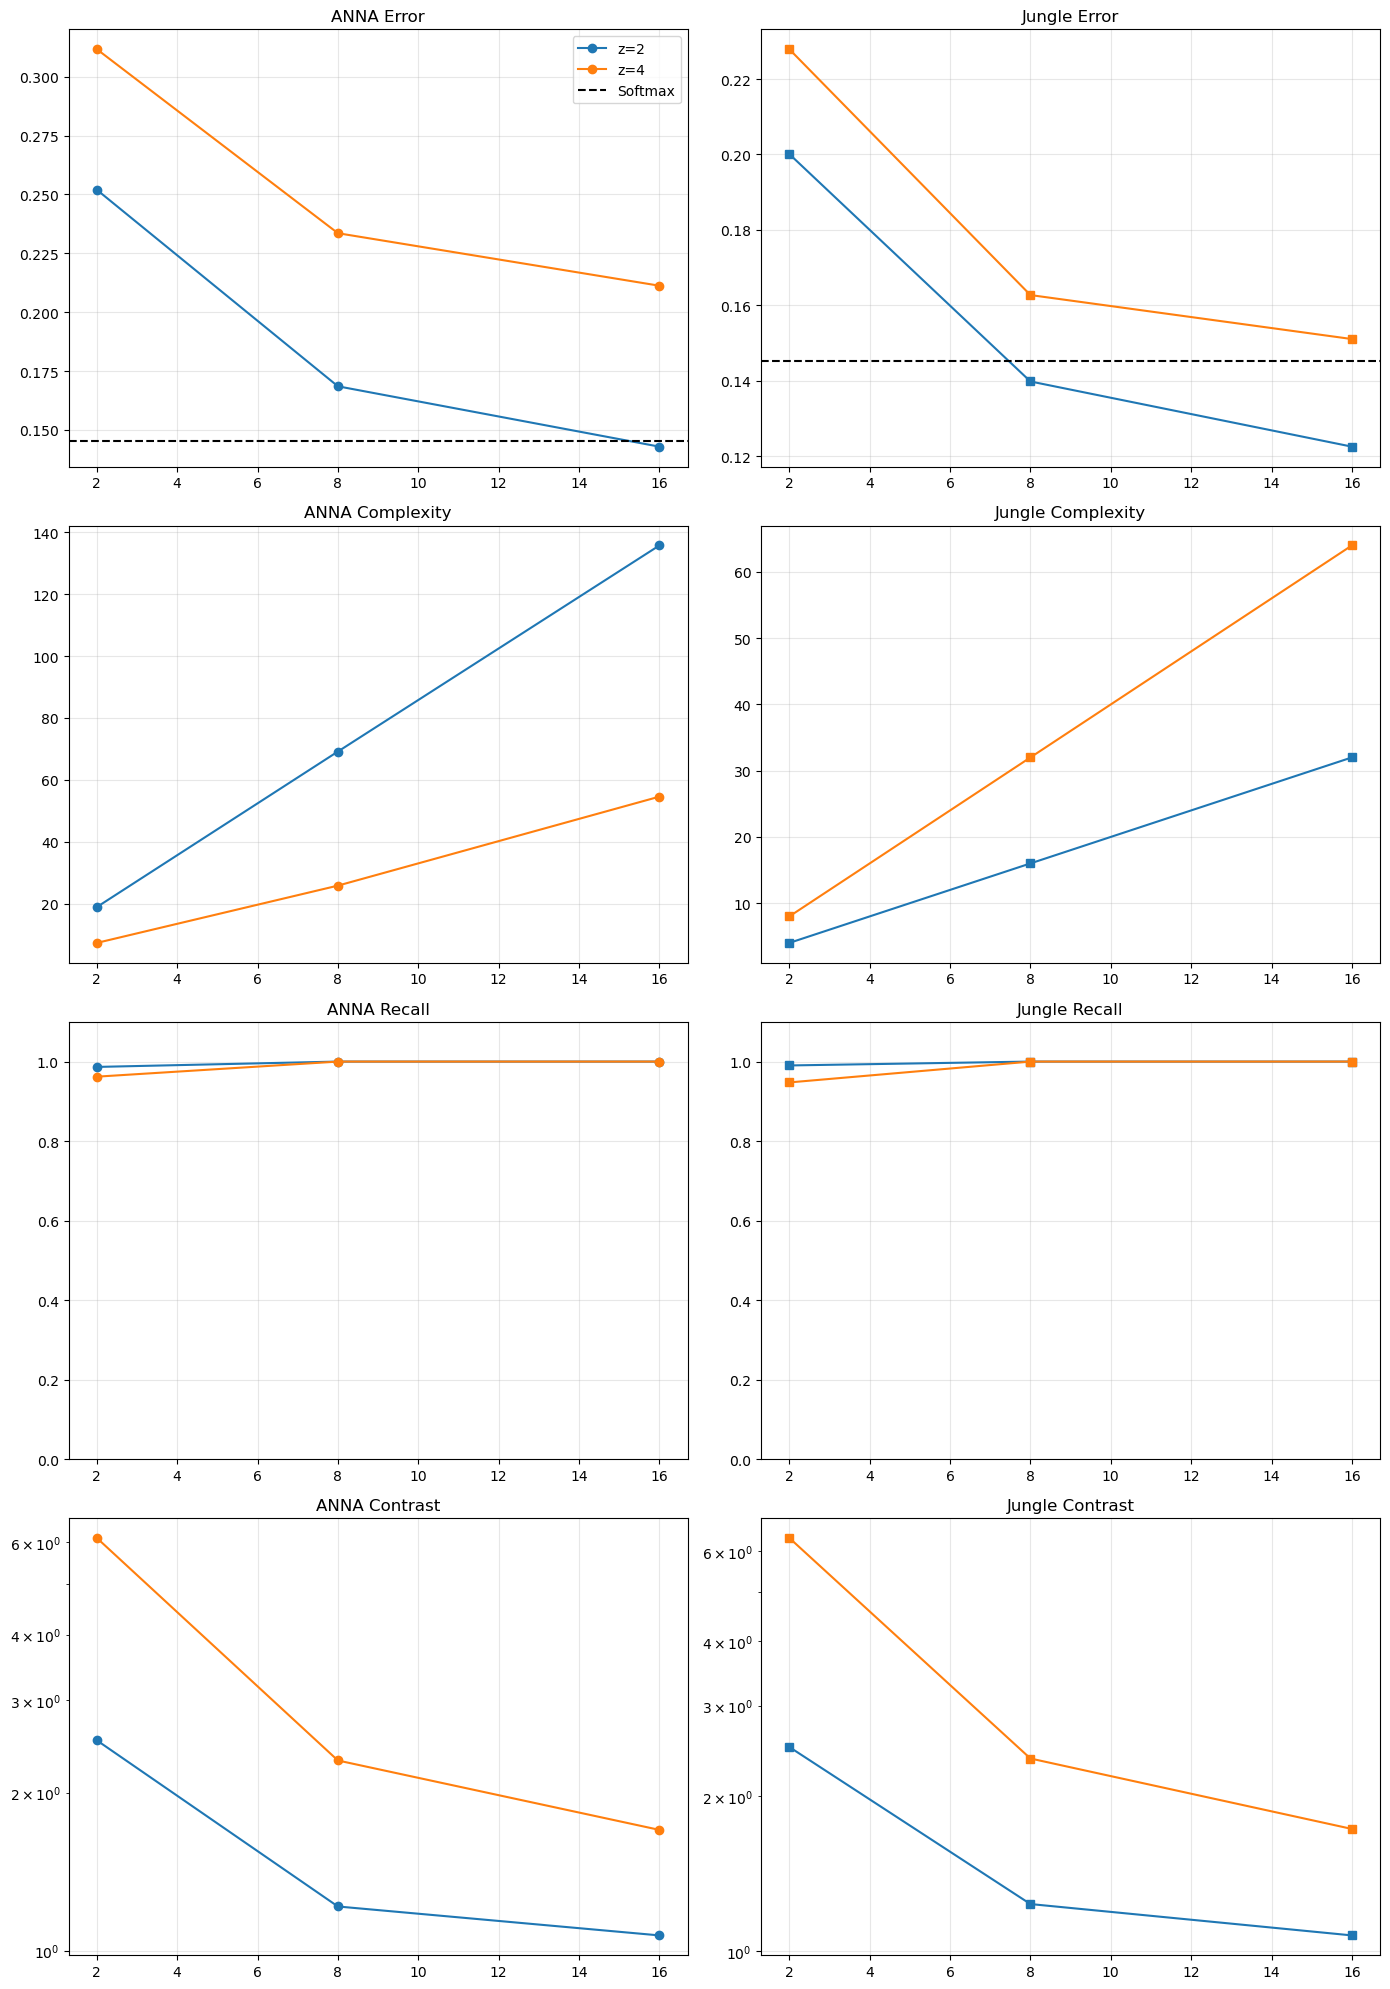


🔍 Visualizing Explicit Recovery (ANNA)...


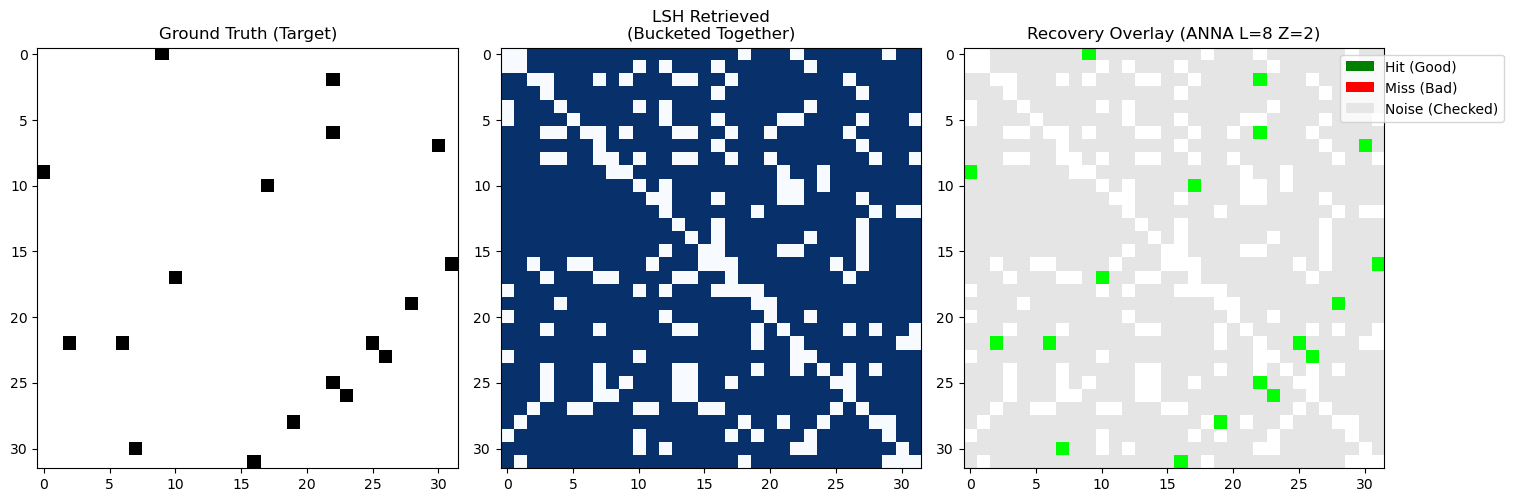


🔍 Visualizing Global Token Interactions (Side-by-Side)...
   Computing Softmax interactions...
Accumulating global token interactions...
   Computing ANNA interactions (L=8, Z=2)...
Accumulating global token interactions...
   Computing Jungle interactions (L=8, Z=2)...
Accumulating global token interactions...


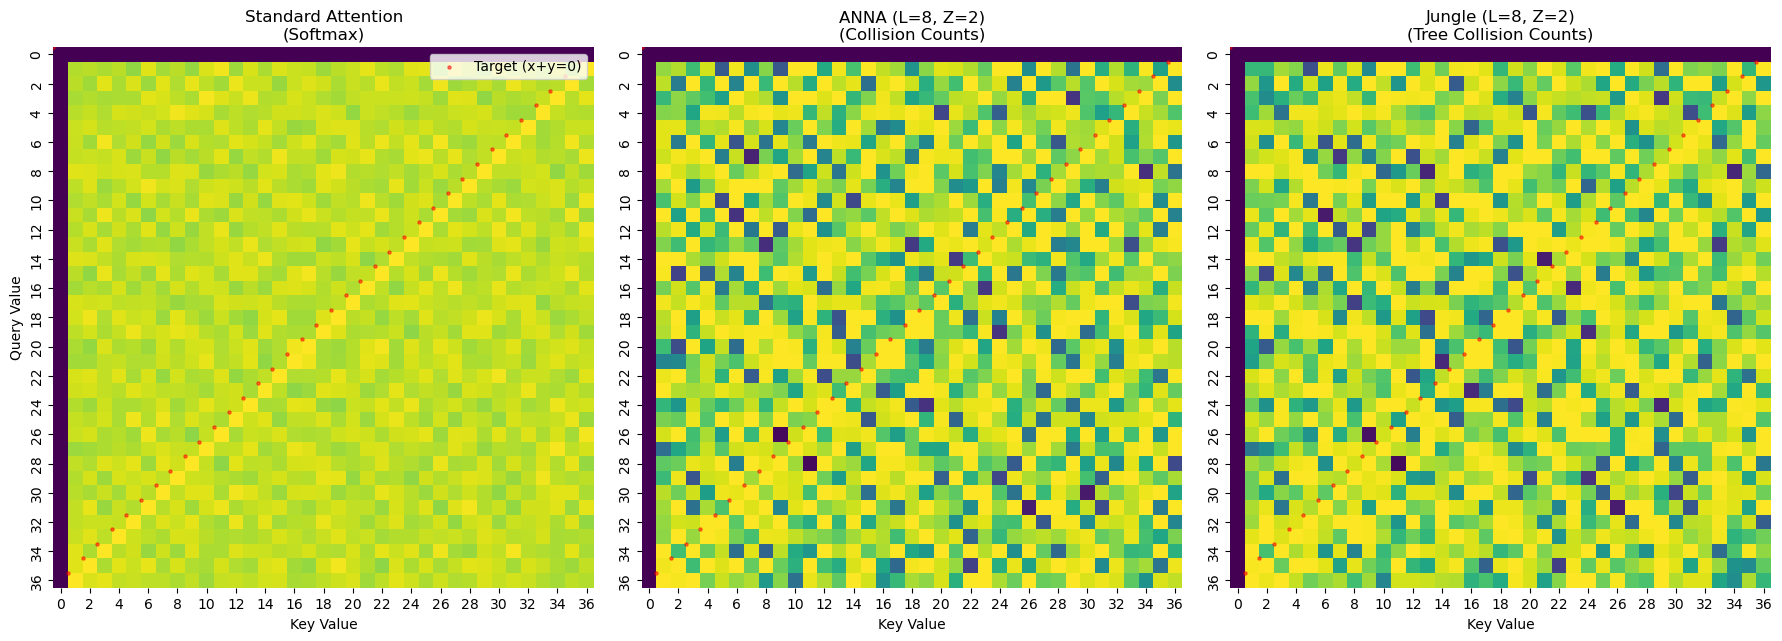

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns # Ensure you have seaborn installed (pip install seaborn)

# ==========================================
# 1. CONFIGURATION
# ==========================================
QUICK_TRAIN = True

if QUICK_TRAIN:
    TRAIN_STEPS = 5000
    DS_SIZE = 2000
    BATCH_SIZE = 64
    RUNS_PER_POINT = 3
    L_RANGE = [2, 8, 16] 
    Z_RANGE = [2,4]
    TEST_DS_SIZE = 100 
else:
    TRAIN_STEPS = 20000     
    DS_SIZE = 20000
    BATCH_SIZE = 64
    RUNS_PER_POINT = 3     
    L_RANGE = [1, 2, 4, 8, 16, 32]
    Z_RANGE = [2, 4, 6]
    TEST_DS_SIZE = 500

LR = 0.005
BETA = 0.1              
SEQ_LEN = 32            
MODULO = 37             
EMBED_DIM = 64          
MLP_DIM = 256           
SEED = 42

if torch.cuda.is_available(): DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available(): DEVICE = torch.device("mps")
else: DEVICE = torch.device("cpu")
print(f"✅ Device: {DEVICE}")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# 2. DATASET
# ==========================================
class Match2Dataset(Dataset):
    def __init__(self, size, seq_len, modulo):
        self.size = size
        self.seq_len = seq_len
        self.modulo = modulo
        self.data = self._generate_balanced_data_algo3()

    def _compute_labels(self, X):
        x_col = X.unsqueeze(1)
        x_row = X.unsqueeze(2)
        # Match if sum is 0 mod M
        matches = ((x_col + x_row) % self.modulo == 0).any(dim=2).long()
        return matches

    def _generate_balanced_data_algo3(self):
        bins = {0: [], 1: [], 2: [], 3: []}
        target_per_bin = self.size // 4
        iter_count = 0
        while any(len(b) < target_per_bin for b in bins.values()) and iter_count < 100000:
            iter_count += 1
            X_cand = torch.randint(1, self.modulo, (10, self.seq_len))
            Y_cand = self._compute_labels(X_cand)
            means = Y_cand.float().mean(dim=1)
            for i in range(10):
                p = means[i].item()
                if p < 0.25: bin_idx = 0
                elif p < 0.50: bin_idx = 1
                elif p < 0.75: bin_idx = 2
                else: bin_idx = 3
                if len(bins[bin_idx]) < target_per_bin:
                    bins[bin_idx].append((X_cand[i], Y_cand[i]))
                    if target_per_bin - len(bins[bin_idx]) > 0:
                        perm = torch.randperm(self.seq_len)
                        bins[bin_idx].append((X_cand[i][perm], Y_cand[i][perm]))

        all_X, all_Y = [], []
        for b in bins.values():
            for item in b[:target_per_bin]:
                all_X.append(item[0])
                all_Y.append(item[1])
        
        if not all_X: return torch.zeros(1, self.seq_len), torch.zeros(1)
        
        X_final = torch.stack(all_X)
        Y_final = torch.stack(all_Y)
        perm_idx = torch.randperm(X_final.size(0))
        return X_final[perm_idx], Y_final[perm_idx]

    def __len__(self): return len(self.data[0])
    def __getitem__(self, idx): return self.data[0][idx], self.data[1][idx]

# ==========================================
# 3. MODELS
# ==========================================
class StandardAttention(nn.Module):
    def __init__(self, embed_dim, beta):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=False)
        self.beta = beta
        self.complexity_score = SEQ_LEN 

    def forward(self, x, return_attn=False):
        Q = F.normalize(self.W_q(x), p=2, dim=-1)
        K = F.normalize(self.W_k(x), p=2, dim=-1)
        V = self.W_v(x)
        attn_scores = torch.bmm(Q, K.transpose(1, 2)) * self.beta
        attn_probs = F.softmax(attn_scores, dim=-1)
        if return_attn:
            return self.W_o(torch.bmm(attn_probs, V)), attn_probs
        return self.W_o(torch.bmm(attn_probs, V))

class ANNA_Attention(nn.Module):
    def __init__(self, std_attn, l, z):
        super().__init__()
        self.W_q = std_attn.W_q; self.W_k = std_attn.W_k
        self.W_v = std_attn.W_v; self.W_o = std_attn.W_o
        self.l = l; self.z = z
        self.complexity_score = 0

    def forward(self, x, return_attn=False):
        B, N, D = x.shape
        device = x.device
        with torch.no_grad():
            Q = F.normalize(self.W_q(x), p=2, dim=-1)
            K = F.normalize(self.W_k(x), p=2, dim=-1)
            V = self.W_v(x)
            
            final_out = torch.zeros_like(Q)
            powers = (2**torch.arange(self.z, device=device)).long().view(1, 1, -1)
            
            if return_attn:
                retrieval_mask = torch.zeros(B, N, N, device=device)
            
            total_collisions = 0
            for _ in range(self.l):
                R = torch.randn(D, self.z, device=device)
                b_q = ((Q @ R > 0).long() * powers).sum(-1)
                b_k = ((K @ R > 0).long() * powers).sum(-1)
                
                if return_attn:
                    matches = (b_q.unsqueeze(2) == b_k.unsqueeze(1)).float()
                    retrieval_mask = torch.clamp(retrieval_mask + matches, max=1.0)

                num_buckets = 2**self.z
                batch_offsets = (torch.arange(B, device=device) * num_buckets).view(B, 1)
                global_b_q = (b_q + batch_offsets).view(-1)
                global_b_k = (b_k + batch_offsets).view(-1)
                total_bins = B * num_buckets
                
                v_sum_global = torch.zeros(total_bins, D, device=device)
                v_sum_global.index_add_(0, global_b_k, V.reshape(-1, D))
                counts_global = torch.zeros(total_bins, 1, device=device)
                counts_global.index_add_(0, global_b_k, torch.ones(B*N, 1, device=device))
                
                query_costs = counts_global[global_b_q]
                total_collisions += query_costs.sum().item() / (B * N)
                
                safe_counts = torch.clamp(counts_global, min=1.0)
                centroids = v_sum_global / safe_counts
                final_out += centroids[global_b_q].view(B, N, D)
            
            self.complexity_score = total_collisions
            if return_attn:
                return self.W_o(final_out / self.l), retrieval_mask
            return self.W_o(final_out / self.l)

class Jungle_Attention(nn.Module):
    def __init__(self, std_attn, l, z):
        super().__init__()
        self.W_q = std_attn.W_q; self.W_k = std_attn.W_k
        self.W_v = std_attn.W_v; self.W_o = std_attn.W_o
        self.l = l; self.z = z
        self.complexity_score = 0

    def forward(self, x, return_attn=False):
        B, N, D = x.shape
        device = x.device
        with torch.no_grad():
            Q = F.normalize(self.W_q(x), p=2, dim=-1)
            K = F.normalize(self.W_k(x), p=2, dim=-1)
            V = self.W_v(x)
            
            self.complexity_score = float(self.l * self.z)
            forest_out = torch.zeros_like(Q)
            powers = (2**torch.arange(self.z, device=device)).long().view(1, 1, -1)
            
            if return_attn:
                retrieval_mask = torch.zeros(B, N, N, device=device)

            for _ in range(self.l):
                R = torch.randn(D, self.z, device=device)
                h_q_raw = (Q @ R) > 0 
                h_k_raw = (K @ R) > 0
                tree_path_sum = torch.zeros_like(Q)
                
                for d in range(1, self.z + 1):
                    mask = torch.zeros((1, 1, self.z), device=device, dtype=torch.long)
                    mask[:, :, :d] = 1 
                    masked_powers = powers * mask
                    b_q = (h_q_raw.long() * masked_powers).sum(-1)
                    b_k = (h_k_raw.long() * masked_powers).sum(-1)
                    
                    if return_attn and d == self.z:
                        matches = (b_q.unsqueeze(2) == b_k.unsqueeze(1)).float()
                        retrieval_mask = torch.clamp(retrieval_mask + matches, max=1.0)

                    num_buckets_d = 2**d
                    batch_offsets = (torch.arange(B, device=device) * num_buckets_d).view(B, 1)
                    global_b_q = (b_q + batch_offsets).view(-1)
                    global_b_k = (b_k + batch_offsets).view(-1)
                    total_bins = B * num_buckets_d
                    
                    v_sum = torch.zeros(total_bins, D, device=device)
                    v_sum.index_add_(0, global_b_k, V.reshape(-1, D))
                    counts = torch.zeros(total_bins, 1, device=device)
                    counts.index_add_(0, global_b_k, torch.ones(B*N, 1, device=device))
                    centroids = v_sum / torch.clamp(counts, min=1.0)
                    tree_path_sum += centroids[global_b_q].view(B, N, D)
                
                forest_out += (tree_path_sum / self.z)
            
            if return_attn:
                return self.W_o(forest_out / self.l), retrieval_mask
            return self.W_o(forest_out / self.l)

class Match2Transformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(MODULO, EMBED_DIM)
        self.pos = nn.Parameter(torch.randn(1, SEQ_LEN, EMBED_DIM))
        self.attn = StandardAttention(EMBED_DIM, BETA)
        self.ln1 = nn.LayerNorm(EMBED_DIM); self.ln2 = nn.LayerNorm(EMBED_DIM)
        self.mlp = nn.Sequential(nn.Linear(EMBED_DIM, MLP_DIM), nn.GELU(), nn.Linear(MLP_DIM, EMBED_DIM))
        self.head = nn.Linear(EMBED_DIM, 2)

    def forward(self, x, return_attn=False):
        x = self.embed(x) + self.pos
        attn_out = self.attn(x, return_attn=return_attn)
        if return_attn:
            x_attn, attn_map = attn_out
            x = self.ln1(x + x_attn)
        else:
            x = self.ln1(x + attn_out)
        
        x = self.ln2(x + self.mlp(x))
        out = self.head(x)
        if return_attn: return out, attn_map
        return out

    def to_anna(self, l, z): self.attn = ANNA_Attention(self.attn, l, z)
    def to_jungle(self, l, z): self.attn = Jungle_Attention(self.attn, l, z)
    def to_softmax(self, state):
        self.attn = StandardAttention(EMBED_DIM, BETA).to(self.embed.weight.device)
        self.load_state_dict(state)

# ==========================================
# 4. METRICS & ANALYSIS TOOLS
# ==========================================
def calculate_lsh_metrics(model, x):
    model.eval()
    with torch.no_grad():
        _, attn_map = model(x, return_attn=True)
    
    retrieved_mask = (attn_map > 0.0).float()
    x_i = x.unsqueeze(2); x_j = x.unsqueeze(1)
    true_matches = ((x_i + x_j) % MODULO == 0).float()
    diag_mask = torch.eye(SEQ_LEN, device=x.device).unsqueeze(0).expand(x.size(0), -1, -1)
    
    valid_matches = true_matches * (1.0 - diag_mask)
    hits_p1 = (valid_matches * retrieved_mask).sum()
    total_p1 = valid_matches.sum()
    p1 = (hits_p1 / total_p1).item() if total_p1 > 0 else 0.0
    
    noise_region = (1.0 - true_matches) * (1.0 - diag_mask)
    hits_p2 = (noise_region * retrieved_mask).sum()
    total_p2 = noise_region.sum()
    p2 = (hits_p2 / total_p2).item() if total_p2 > 0 else 0.0
    
    ratio = p1 / max(p2, 1e-6)
    return p1, p2, ratio

# ==========================================
# 5. VISUALIZATION FUNCTIONS
# ==========================================
def plot_attention_recovery(model, x, title_suffix=""):
    """
    Shows: Ground Truth vs LSH Retrieved vs Overlay (Green=Hit, Red=Miss)
    """
    model.eval()
    with torch.no_grad():
        _, attn_map = model(x, return_attn=True)
    
    idx = 0 # Take first item
    seq = x[idx]; retrieved_raw = attn_map[idx]
    
    # Binary masks
    retrieved_mask = (retrieved_raw > 0).cpu().numpy()
    
    # Ground Truth
    x_i = seq.unsqueeze(1); x_j = seq.unsqueeze(0)
    gt_mask = ((x_i + x_j) % MODULO == 0).long().cpu().numpy()
    
    np.fill_diagonal(gt_mask, 0)
    np.fill_diagonal(retrieved_mask, 0)

    # RGB Overlay
    N = seq.shape[0]
    img = np.zeros((N, N, 3))
    
    tp = (gt_mask == 1) & (retrieved_mask == 1) # Green
    img[tp] = [0, 1, 0] 
    fn = (gt_mask == 1) & (retrieved_mask == 0) # Red (Miss)
    img[fn] = [1, 0, 0] 
    fp = (gt_mask == 0) & (retrieved_mask == 1) # Gray (Noise)
    img[fp] = [0.9, 0.9, 0.9] 
    tn = (gt_mask == 0) & (retrieved_mask == 0) # White
    img[tn] = [1, 1, 1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(gt_mask, cmap='Greys', interpolation='nearest')
    axes[0].set_title("Ground Truth (Target)")
    
    axes[1].imshow(retrieved_mask, cmap='Blues', interpolation='nearest')
    axes[1].set_title(f"LSH Retrieved\n(Bucketed Together)")

    axes[2].imshow(img, interpolation='nearest')
    axes[2].set_title(f"Recovery Overlay {title_suffix}")
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green', label='Hit (Good)'),
        Patch(facecolor='red', label='Miss (Bad)'),
        Patch(facecolor='#e6e6e6', label='Noise (Checked)')
    ]
    axes[2].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1))
    plt.tight_layout(); plt.show()

def analyze_token_interactions(model, data_loader, modulo, device):
    """
    Aggregates attention scores by Token Value to find global patterns.
    """
    model.eval()
    value_attn_sum = torch.zeros((modulo, modulo), device=device)
    value_counts = torch.zeros((modulo, modulo), device=device)
    
    print("Accumulating global token interactions...")
    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device)
            _, attn_map = model(x, return_attn=True) 
            B, N = x.shape
            
            # Vectorized Scatter Add
            q_vals = x.unsqueeze(2).expand(B, N, N).reshape(-1)
            k_vals = x.unsqueeze(1).expand(B, N, N).reshape(-1)
            attn_flat = attn_map.reshape(-1)
            
            flat_indices = q_vals * modulo + k_vals
            value_attn_sum.view(-1).scatter_add_(0, flat_indices, attn_flat)
            value_counts.view(-1).scatter_add_(0, flat_indices, torch.ones_like(attn_flat))

    valid_mask = value_counts > 0
    mean_attn = torch.zeros_like(value_attn_sum)
    mean_attn[valid_mask] = value_attn_sum[valid_mask] / value_counts[valid_mask]
    return mean_attn.cpu().numpy()

def plot_token_interaction_heatmap(interaction_matrix, modulo):
    plt.figure(figsize=(10, 8))
    vmax = np.percentile(interaction_matrix, 99.5) 
    sns.heatmap(interaction_matrix, cmap='viridis', square=True, vmax=vmax)
    
    # Overlay Theoretical Match Line: y = -x (mod M)
    x_points = np.arange(modulo)
    y_points = (modulo - x_points) % modulo
    plt.scatter(y_points, x_points, color='red', s=10, label='Target (x+y=0)')
    
    plt.title("Global Token-to-Token Attention\n(Checks intuition: Do values attend to their complement?)")
    plt.xlabel("Key Token Value"); plt.ylabel("Query Token Value")
    plt.legend(loc='upper right'); plt.show()

# ==========================================
# 6. MAIN EXECUTION
# ==========================================
def train_and_plot():
    print(f"🚀 Training | QuickTrain: {QUICK_TRAIN}")
    model = Match2Transformer().to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=LR)
    ds = Match2Dataset(DS_SIZE, SEQ_LEN, MODULO) 
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    
    model.train()
    iter_dl = iter(dl)
    for i in range(TRAIN_STEPS):
        try: x, y = next(iter_dl)
        except: iter_dl = iter(dl); x, y = next(iter_dl)
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = F.cross_entropy(model(x).view(-1, 2), y.view(-1))
        loss.backward(); opt.step()
        if i % (TRAIN_STEPS // 5) == 0: print(f"Step {i} | Loss: {loss.item():.4f}")

    # Eval Setup
    print("\n🔬 Eval...")
    clean_state = model.state_dict()
    test_ds = Match2Dataset(TEST_DS_SIZE, SEQ_LEN, MODULO)
    test_loader = DataLoader(test_ds, batch_size=TEST_DS_SIZE) 
    test_x, test_y = next(iter(test_loader))
    test_x, test_y = test_x.to(DEVICE), test_y.to(DEVICE)
    
    # Baseline
    model.eval()
    with torch.no_grad():
        preds = model(test_x).argmax(-1)
        base_err = 1.0 - (preds == test_y).float().mean().item()
    print(f"Baseline Error: {base_err:.4f}")

    # Storage
    res = {'ANNA': {}, 'Jungle': {}}
    for z in Z_RANGE:
        res['ANNA'][z] = {'err': [], 'ops': [], 'p1': [], 'ratio': []}
        res['Jungle'][z] = {'err': [], 'ops': [], 'p1': [], 'ratio': []}
        
    print("--- Running Approximations ---")
    for z in Z_RANGE:
        print(f"   z={z}...")
        for l in L_RANGE:
            # ANNA
            m_err, m_ops, m_p1, m_ratio = [], [], [], []
            for _ in range(RUNS_PER_POINT):
                model.to_softmax(clean_state); model.to_anna(l, z); model.eval()
                with torch.no_grad():
                    m_err.append(1.0 - (model(test_x).argmax(-1) == test_y).float().mean().item())
                    m_ops.append(model.attn.complexity_score)
                    p1, p2, ratio = calculate_lsh_metrics(model, test_x)
                    m_p1.append(p1); m_ratio.append(ratio)
            res['ANNA'][z]['err'].append(np.mean(m_err))
            res['ANNA'][z]['ops'].append(np.mean(m_ops))
            res['ANNA'][z]['p1'].append(np.mean(m_p1))
            res['ANNA'][z]['ratio'].append(np.mean(m_ratio))

            # Jungle
            m_err, m_ops, m_p1, m_ratio = [], [], [], []
            for _ in range(RUNS_PER_POINT):
                model.to_softmax(clean_state); model.to_jungle(l, z); model.eval()
                with torch.no_grad():
                    m_err.append(1.0 - (model(test_x).argmax(-1) == test_y).float().mean().item())
                    m_ops.append(model.attn.complexity_score)
                    p1, p2, ratio = calculate_lsh_metrics(model, test_x)
                    m_p1.append(p1); m_ratio.append(ratio)
            res['Jungle'][z]['err'].append(np.mean(m_err))
            res['Jungle'][z]['ops'].append(np.mean(m_ops))
            res['Jungle'][z]['p1'].append(np.mean(m_p1))
            res['Jungle'][z]['ratio'].append(np.mean(m_ratio))
    
    # 1. Plot Metrics Grid
    print("\n📈 Plotting Metrics Grid...")
    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    # Error
    ax = axes[0,0]
    for z in Z_RANGE: ax.plot(L_RANGE, res['ANNA'][z]['err'], marker='o', label=f'z={z}')
    ax.axhline(y=base_err, color='k', linestyle='--', label='Softmax')
    ax.set_title("ANNA Error"); ax.legend(); ax.grid(True, alpha=0.3)
    ax = axes[0,1]
    for z in Z_RANGE: ax.plot(L_RANGE, res['Jungle'][z]['err'], marker='s', label=f'z={z}')
    ax.axhline(y=base_err, color='k', linestyle='--', label='Softmax')
    ax.set_title("Jungle Error"); ax.grid(True, alpha=0.3)
    # Ops
    ax = axes[1,0]
    for z in Z_RANGE: ax.plot(L_RANGE, res['ANNA'][z]['ops'], marker='o', label=f'z={z}')
    ax.set_title("ANNA Complexity"); ax.grid(True, alpha=0.3)
    ax = axes[1,1]
    for z in Z_RANGE: ax.plot(L_RANGE, res['Jungle'][z]['ops'], marker='s', label=f'z={z}')
    ax.set_title("Jungle Complexity"); ax.grid(True, alpha=0.3)
    # Recall
    ax = axes[2,0]
    for z in Z_RANGE: ax.plot(L_RANGE, res['ANNA'][z]['p1'], marker='o', label=f'z={z}')
    ax.set_title("ANNA Recall"); ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.3)
    ax = axes[2,1]
    for z in Z_RANGE: ax.plot(L_RANGE, res['Jungle'][z]['p1'], marker='s', label=f'z={z}')
    ax.set_title("Jungle Recall"); ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.3)
    # Contrast
    ax = axes[3,0]
    for z in Z_RANGE: ax.plot(L_RANGE, res['ANNA'][z]['ratio'], marker='o', label=f'z={z}')
    ax.set_yscale('log'); ax.set_title("ANNA Contrast"); ax.grid(True, alpha=0.3)
    ax = axes[3,1]
    for z in Z_RANGE: ax.plot(L_RANGE, res['Jungle'][z]['ratio'], marker='s', label=f'z={z}')
    ax.set_yscale('log'); ax.set_title("Jungle Contrast"); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # 2. Explicit Recovery Visualization
    print("\n🔍 Visualizing Explicit Recovery (ANNA)...")
    # Use middle L and lowest Z for a good mix of hits and misses
    demo_L = L_RANGE[len(L_RANGE)//2]
    demo_Z = Z_RANGE[0] 
    
    model.to_softmax(clean_state); model.to_anna(l=demo_L, z=demo_Z)
    plot_attention_recovery(model, test_x, title_suffix=f"(ANNA L={demo_L} Z={demo_Z})")

# ... (Keep previous parts of train_and_plot as they are) ...

    # ==========================================
    # 3. Global Interaction Visualization (Side-by-Side)
    # ==========================================
    print("\n🔍 Visualizing Global Token Interactions (Side-by-Side)...")
    
    # Reuse the demo config determined in step 2
    # If step 2 didn't run, define defaults:
    if 'demo_L' not in locals(): demo_L = L_RANGE[len(L_RANGE)//2]
    if 'demo_Z' not in locals(): demo_Z = Z_RANGE[0]

    # Create a specific loader for this analysis to get a good average
    interaction_loader = DataLoader(Match2Dataset(1000, SEQ_LEN, MODULO), batch_size=64)
    
    # A. Standard Softmax
    print("   Computing Softmax interactions...")
    model.to_softmax(clean_state)
    mat_std = analyze_token_interactions(model, interaction_loader, MODULO, DEVICE)
    
    # B. ANNA
    print(f"   Computing ANNA interactions (L={demo_L}, Z={demo_Z})...")
    model.to_softmax(clean_state) # Reset to clean weights
    model.to_anna(l=demo_L, z=demo_Z)
    mat_anna = analyze_token_interactions(model, interaction_loader, MODULO, DEVICE)
    
    # C. Jungle
    print(f"   Computing Jungle interactions (L={demo_L}, Z={demo_Z})...")
    model.to_softmax(clean_state) # Reset to clean weights
    model.to_jungle(l=demo_L, z=demo_Z)
    mat_jungle = analyze_token_interactions(model, interaction_loader, MODULO, DEVICE)
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Helper for the "Target" line (x + y = 0 mod 37)
    x_line = np.arange(MODULO)
    y_line = (MODULO - x_line) % MODULO
    
    # 1. Standard
    # Use a robust max value (99.5 percentile) so outlines don't get washed out
    vmax = np.percentile(mat_std, 99.5) 
    
    sns.heatmap(mat_std, ax=axes[0], cmap='viridis', square=True, cbar=False, vmax=vmax)
    axes[0].scatter(y_line, x_line, color='red', s=5, alpha=0.5, label='Target (x+y=0)')
    axes[0].set_title("Standard Attention\n(Softmax)")
    axes[0].set_ylabel("Query Value"); axes[0].set_xlabel("Key Value")
    axes[0].legend(loc='upper right')
    
    # 2. ANNA
    vmax_anna = np.percentile(mat_anna, 99.5)
    sns.heatmap(mat_anna, ax=axes[1], cmap='viridis', square=True, cbar=False, vmax=vmax_anna)
    axes[1].scatter(y_line, x_line, color='red', s=5, alpha=0.5)
    axes[1].set_title(f"ANNA (L={demo_L}, Z={demo_Z})\n(Collision Counts)")
    axes[1].set_xlabel("Key Value")
    
    # 3. Jungle
    vmax_jungle = np.percentile(mat_jungle, 99.5)
    sns.heatmap(mat_jungle, ax=axes[2], cmap='viridis', square=True, cbar=False, vmax=vmax_jungle)
    axes[2].scatter(y_line, x_line, color='red', s=5, alpha=0.5)
    axes[2].set_title(f"Jungle (L={demo_L}, Z={demo_Z})\n(Tree Collision Counts)")
    axes[2].set_xlabel("Key Value")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_and_plot()